# MISO wind, solar, and load validation

Compare 2023 MISO actuals with modeled wind, solar, and load using the EIA-860 2022
renewable fleet. Metrics use all 8,760 UTC hours; the figure shows January in Central
time. No-loss and scalar-loss curves are sensitivities, not changes to the released
2024-fleet scenario products.

**Inputs:** The bundled 2022 capacity manifest, two fleet-CF files, renewable and load
actuals, and the historical MISO forecast.

**Requirements:** The repository environment. All inputs are bundled; no archive download or extraction is needed.

**Outputs:** The annual metric CSV and January PNG under
`data_outputs/validation/miso_wind_solar_load_validation/`, with both results displayed inline.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).


## Setup

Run this notebook from `notebooks/validation`. All inputs are bundled, so this validation runs offline.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

VALIDATION_YEAR = 2023
WIND_LOSS_PERCENT = 20.0
SOLAR_LOSS_PERCENT = 14.075660705566406
EXPECTED_PLOT_HOURS = 744
LOCAL_TIMEZONE = "America/Chicago"

OUTPUT_DIR = Path("../../data_outputs/validation/miso_wind_solar_load_validation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Read and align the hourly inputs

Every series must have unique timestamps. Only common, complete 2023 UTC hours enter the comparison.

In [2]:
# Select the 2022 MISO nameplate capacities used for this validation.
capacity = pd.read_csv("../../manifests/eia860_2022_operable_capacity_manifest.csv")
capacity = capacity.loc[capacity["BA"].eq("MISO")]
assert len(capacity) == 1, "Expected exactly one MISO capacity row."
capacity_row = capacity.iloc[0]
installed_wind_mw = float(capacity_row["Installed Wind (MW)"])
installed_solar_mw = float(capacity_row["Installed Solar (MW)"])

# Read modeled capacity factors and observed renewable generation.
wind_cf = pd.read_csv("../../data_inputs/eia860/2022_fleet_validation_cf/MISO_wind_bchrrr_2023.csv", usecols=["time_utc", "wind_cf"])
solar_cf = pd.read_csv("../../data_inputs/eia860/2022_fleet_validation_cf/MISO_solar_nsrdb_2023.csv", usecols=["time_utc", "solar_cf"])
wind_actual = pd.read_csv("../../data_inputs/renewable_actuals/MISO_wind_2023.csv", usecols=["time_utc", "wind_actual_mw"])
solar_actual = pd.read_csv("../../data_inputs/renewable_actuals/MISO_solar_2023.csv", usecols=["time_utc", "solar_actual_mw"])

# Give the actual and forecast load columns distinct names before joining.
load_actual = pd.read_csv("../../data_inputs/load_actuals/raw/MISO_hourly_load.csv", usecols=["Time_UTC", "Load"])
load_actual = load_actual.rename(
    columns={
        "Time_UTC": "time_utc",
        "Load": "load_actual_mw",
    }
)
load_modeled = pd.read_csv("../../data_inputs/examples/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv.gz", usecols=["time_utc", "load_mw"])
load_modeled = load_modeled.rename(columns={"load_mw": "load_modeled_mw"})

frames = [wind_cf, solar_cf, wind_actual, solar_actual, load_actual, load_modeled]
for frame in frames:
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    assert frame["time_utc"].is_unique, "Input timestamps must be unique."

# Align all six inputs by UTC time and keep the validation year.
indexed_frames = []
for frame in frames:
    indexed_frame = frame.set_index("time_utc")
    indexed_frames.append(indexed_frame)

hourly = pd.concat(indexed_frames, axis=1, join="inner")
hourly = hourly.reset_index()
in_validation_year = hourly["time_utc"].dt.year.eq(VALIDATION_YEAR)
hourly = hourly.loc[in_validation_year]
hourly = hourly.reset_index(drop=True)
assert len(hourly) == 8760 and hourly["time_utc"].is_unique, "Expected 8,760 aligned 2023 hours."
assert hourly.drop(columns="time_utc").notna().all().all(), "Aligned inputs contain missing values."

## Step 2: Convert capacity factors to generation

Multiply each CF by its 2022 nameplate capacity, then apply the fixed loss fractions. Load is compared directly.

In [3]:
hourly["wind_modeled_mw_no_loss"] = hourly["wind_cf"] * installed_wind_mw
wind_loss_multiplier = 1 - WIND_LOSS_PERCENT / 100
hourly["wind_modeled_mw_with_loss"] = hourly["wind_modeled_mw_no_loss"] * wind_loss_multiplier

hourly["solar_modeled_mw_no_loss"] = hourly["solar_cf"] * installed_solar_mw
solar_loss_multiplier = 1 - SOLAR_LOSS_PERCENT / 100
hourly["solar_modeled_mw_with_loss"] = hourly["solar_modeled_mw_no_loss"] * solar_loss_multiplier

## Step 3: Calculate annual validation metrics

Error is modeled minus actual MW. MAE and RMSE measure disagreement; bias gives its direction.

In [4]:
metric_cases = [
    ("Wind: 0% loss", "wind_actual_mw", "wind_modeled_mw_no_loss"),
    (f"Wind: {WIND_LOSS_PERCENT:g}% loss", "wind_actual_mw", "wind_modeled_mw_with_loss"),
    ("Solar: 0% loss", "solar_actual_mw", "solar_modeled_mw_no_loss"),
    (f"Solar: {SOLAR_LOSS_PERCENT:.1f}% loss", "solar_actual_mw", "solar_modeled_mw_with_loss"),
    ("Load", "load_actual_mw", "load_modeled_mw"),
]
metric_rows = []

for case, actual_column, modeled_column in metric_cases:
    actual_values = hourly[actual_column]
    modeled_values = hourly[modeled_column]
    error = modeled_values - actual_values
    absolute_error = error.abs()
    squared_error = error**2
    mean_squared_error = np.mean(squared_error)
    rmse = np.sqrt(mean_squared_error)

    metric_rows.append(
        {
            "case": case,
            "mae_mw": absolute_error.mean(),
            "rmse_mw": rmse,
            "bias_mw": error.mean(),
            "n_obs": int(error.notna().sum()),
        }
    )

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUTPUT_DIR / "miso_2023_loss_sensitivity_metrics.csv", index=False)

# Round a display copy; the saved CSV retains the calculated precision.
metrics_display = metrics.rename(
    columns={
        "case": "Case",
        "mae_mw": "MAE (MW)",
        "rmse_mw": "RMSE (MW)",
        "bias_mw": "Bias (MW)",
        "n_obs": "Hours compared",
    }
)
metrics_display = metrics_display.set_index("Case")
metrics_display = metrics_display.round(
    {
        "MAE (MW)": 1,
        "RMSE (MW)": 1,
        "Bias (MW)": 1,
    }
)
display(metrics_display)

,MAE (MW),RMSE (MW),Bias (MW),Hours compared
Case,,,,
Wind: 0% loss,2421.2,3107.2,1937.0,8760
Wind: 20% loss,1247.8,1599.4,-544.5,8760
Solar: 0% loss,245.3,411.9,157.3,8760
Solar: 14.1% loss,182.0,310.0,33.2,8760
Load,1475.6,1914.0,-320.4,8760


## Step 4: Inspect January

The figure uses local Central time. Its shorter window illustrates hourly behavior; use the annual table above to compare overall errors.

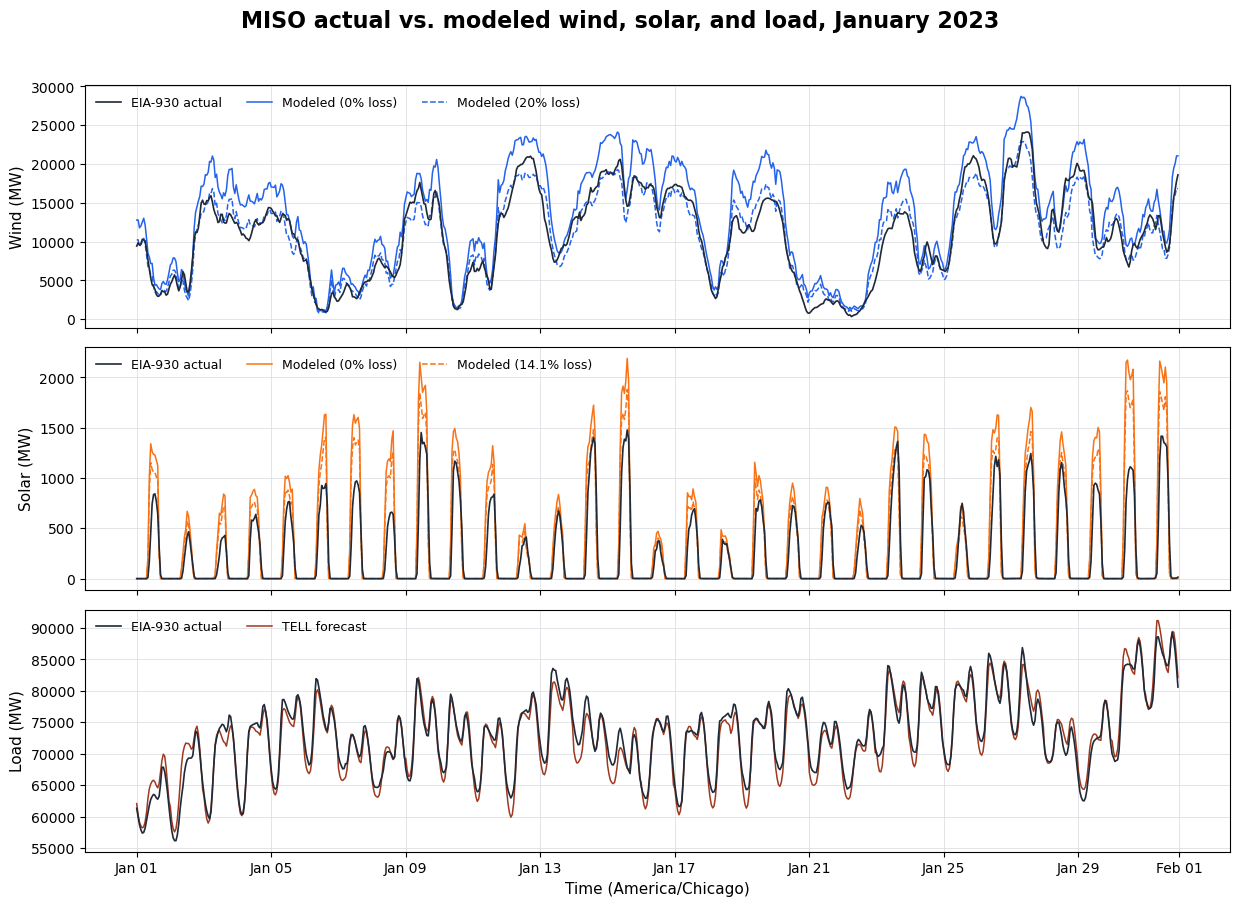

In [5]:
# Shared appearance for this notebook's figures.

PLOT_TITLE = "MISO actual vs. modeled wind, solar, and load, January 2023"
WIND_Y_LABEL = "Wind (MW)"
SOLAR_Y_LABEL = "Solar (MW)"
LOAD_Y_LABEL = "Load (MW)"
X_LABEL = f"Time ({LOCAL_TIMEZONE})"
ACTUAL_COLOR = "#1f2937"
WIND_COLOR = "#2563eb"
SOLAR_COLOR = "#f97316"
LOAD_COLOR = "#9f3a20"
ACTUAL_LINE_WIDTH = 1.2
MODELED_LINE_WIDTH = 1.1
LOSS_LINE_STYLE = "--"

local = hourly.copy()
local["time_local"] = hourly["time_utc"].dt.tz_convert(LOCAL_TIMEZONE)
in_validation_year = local["time_local"].dt.year.eq(VALIDATION_YEAR)
in_january = local["time_local"].dt.month.eq(1)
plot_data = local.loc[in_validation_year & in_january].copy()
assert len(plot_data) == EXPECTED_PLOT_HOURS, f"Expected {EXPECTED_PLOT_HOURS} January hours."

fig, (ax_wind, ax_solar, ax_load) = plt.subplots(3, 1, figsize=(12.5, 9.2), sharex=True)

ax_wind.plot(plot_data["time_local"], plot_data["wind_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="EIA-930 actual", zorder=3)
ax_wind.plot(plot_data["time_local"], plot_data["wind_modeled_mw_no_loss"], color=WIND_COLOR, linewidth=MODELED_LINE_WIDTH, label="Modeled (0% loss)")
ax_wind.plot(plot_data["time_local"], plot_data["wind_modeled_mw_with_loss"], color=WIND_COLOR, linewidth=MODELED_LINE_WIDTH, linestyle=LOSS_LINE_STYLE, label=f"Modeled ({WIND_LOSS_PERCENT:g}% loss)")
ax_wind.set_ylabel(WIND_Y_LABEL)

ax_solar.plot(plot_data["time_local"], plot_data["solar_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="EIA-930 actual", zorder=3)
ax_solar.plot(plot_data["time_local"], plot_data["solar_modeled_mw_no_loss"], color=SOLAR_COLOR, linewidth=MODELED_LINE_WIDTH, label="Modeled (0% loss)")
ax_solar.plot(plot_data["time_local"], plot_data["solar_modeled_mw_with_loss"], color=SOLAR_COLOR, linewidth=MODELED_LINE_WIDTH, linestyle=LOSS_LINE_STYLE, label=f"Modeled ({SOLAR_LOSS_PERCENT:.1f}% loss)")
ax_solar.set_ylabel(SOLAR_Y_LABEL)

ax_load.plot(plot_data["time_local"], plot_data["load_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="EIA-930 actual", zorder=3)
ax_load.plot(plot_data["time_local"], plot_data["load_modeled_mw"], color=LOAD_COLOR, linewidth=MODELED_LINE_WIDTH, label="TELL forecast")
ax_load.set_ylabel(LOAD_Y_LABEL)
ax_load.set_xlabel(X_LABEL)

for axis in (ax_wind, ax_solar, ax_load):
    axis.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
    axis.legend(loc="upper left", frameon=False, ncol=3)

ax_load.xaxis.set_major_locator(mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE))
ax_load.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE))
fig.suptitle(PLOT_TITLE, fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(OUTPUT_DIR / "miso_20230101_20230131_loss_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

## Interpretation

The sensitivity curves show how a constant renewable-loss assumption changes modeled output and annual bias. The assumptions are not calibrated here, and a scalar adjustment cannot resolve differences in hourly timing. The load comparison is independent of those renewable-loss settings.